[DNN] Epoch 1/15, Loss: 1.1813
[DNN] Epoch 2/15, Loss: 1.0536
[DNN] Epoch 3/15, Loss: 1.0135
[DNN] Epoch 4/15, Loss: 0.9867
[DNN] Epoch 5/15, Loss: 0.9611
[DNN] Epoch 6/15, Loss: 0.9409
[DNN] Epoch 7/15, Loss: 0.9439
[DNN] Epoch 8/15, Loss: 0.9347
[DNN] Epoch 9/15, Loss: 0.9188
[DNN] Epoch 10/15, Loss: 0.8997
[DNN] Epoch 11/15, Loss: 0.8854
[DNN] Epoch 12/15, Loss: 0.8984
[DNN] Epoch 13/15, Loss: 0.8813
[DNN] Epoch 14/15, Loss: 0.8793
[DNN] Epoch 15/15, Loss: 0.8641


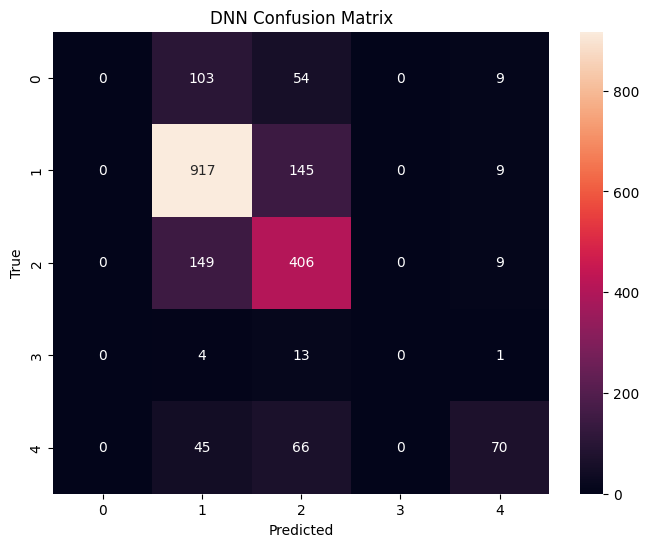

DNN Multiclass AUC Score: 0.7883


In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# Load data
X = np.load("/content/drive/MyDrive/Comp_Vis/X_images.npy", mmap_mode='r')[:10000]
y = np.load('/content/drive/MyDrive/Comp_Vis/y_labels.npy')[:10000]
num_classes = len(np.unique(y))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Convert to PyTorch tensors and rearrange dimensions to (N, C, H, W)
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# Flatten image tensors for DNN input using reshape instead of view
X_train_dnn = X_train.reshape(X_train.size(0), -1)
X_test_dnn = X_test.reshape(X_test.size(0), -1)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train_dnn, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_dnn, y_test), batch_size=64)

# DNN MODEL
class DNNModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(DNNModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_dnn.shape[1]
model = DNNModel(input_dim=input_dim, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 15
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[DNN] Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss / len(train_loader):.4f}")

# Evaluation
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('DNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# AUC
y_true_bin = label_binarize(all_labels, classes=np.arange(num_classes))
y_probs = np.array(all_probs)
auc_score = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')
print(f"DNN Multiclass AUC Score: {auc_score:.4f}")
